## Task 2

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import re


len R = 208787
len t = 208787
Ns = 100


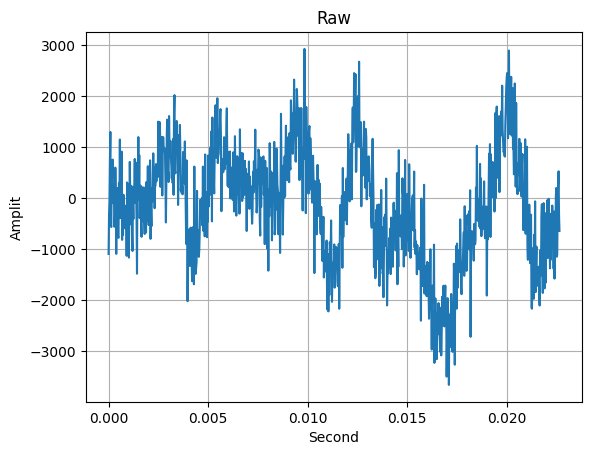

In [36]:

fs = 44100
fc = 4000
Ts = 0.0022676
Ns = int(round(fs * Ts))

data = sio.loadmat("Signals_task2/Signal3.mat")
R = np.ravel(data["R"])
t = np.ravel(data["t"])

print("len R =", len(R))
print("len t =", len(t))
print("Ns =", Ns)

plt.plot(t[:1000], R[:1000])
plt.title("Raw")
plt.xlabel("Second")
plt.ylabel("Amplit")
plt.grid()
plt.show()


## Down conversion

Best timing offset: 38
nbr of samples: 2089


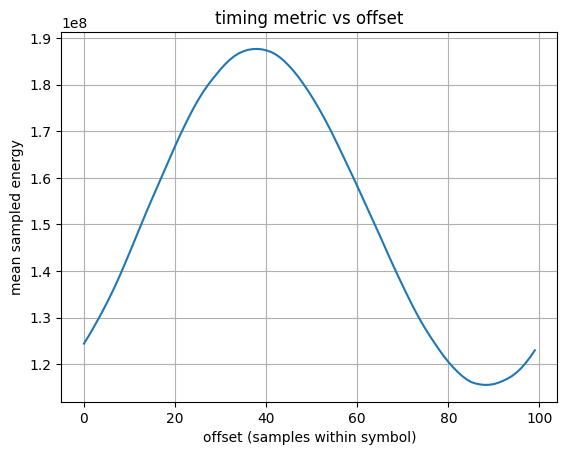

In [37]:
# downconvert to complex
n = np.arange(len(R))
r_bb = 2 * R * np.exp(-1j * 2 * np.pi * fc * n / fs)

# half-cycle sinus pulse
t_pulse = np.arange(Ns) / fs
p = np.sin(np.pi * t_pulse / Ts)

# matched filter
y = np.convolve(r_bb, p[::-1], mode="full")

# Try possible offsets inside one symbol
timing_metric = np.array([np.mean(np.abs(y[o::Ns])**2) for o in range(Ns)])
best_offset = int(np.argmax(timing_metric))

z_all = y[best_offset::Ns]

print("Best timing offset:", best_offset)
print("nbr of samples:", len(z_all))

plt.plot(timing_metric)
plt.title("timing metric vs offset")
plt.xlabel("offset (samples within symbol)")
plt.ylabel("mean sampled energy")
plt.grid()
plt.show()

## Frame alignment with pilots
- Find start and end of payload

Lecture-based pilot extraction result:
  best timing offset: 7
  start index: 2
  end index:   1900
  payload symbols: 1897 (mod 7 = 0)
  mu_tilde: 0.9652416383866937
  pilot_err: 0.02822037449253082
  total score: 0.04040243651181242
  start pilot eq (using c_start): (2+2.0000000000000004j)
  end pilot eq (using c_end):     (2.0000000000000004+2j)


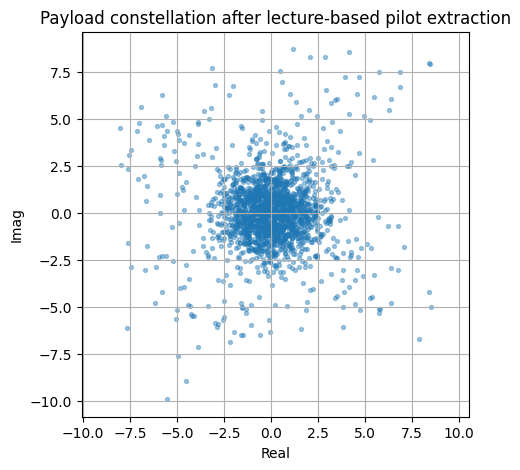

In [38]:
pilot = 2 + 2j

def mu_tilde(win1, win2):
    """
    Lecture-style normalized correlation:
    mu_tilde = |sum(win1 * conj(win2))| / sqrt(sum|win1|^2 * sum|win2|^2)
    """
    num = np.abs(np.vdot(win1, win2))
    den = np.sqrt(np.vdot(win1, win1).real * np.vdot(win2, win2).real) + 1e-12
    return float(num / den)

# Number of strongest candidate indices to test in head/tail regions
K = 40

best = None

for offset in range(Ns):
    z_off = y[offset::Ns]
    if len(z_off) < 300:
        continue

    # One pilot is near start, one near end (Task 2 frame structure)
    head_search = min(220, max(20, len(z_off) // 3))
    tail_search = min(220, max(20, len(z_off) // 3))

    head_idx = np.arange(head_search)
    tail_idx = np.arange(len(z_off) - tail_search, len(z_off))

    # Keep strongest candidates only (pilots have larger magnitude than QPSK data)
    head_candidates = head_idx[np.argsort(np.abs(z_off[head_idx]))[-K:]]
    tail_candidates = tail_idx[np.argsort(np.abs(z_off[tail_idx]))[-K:]]

    for i_start in head_candidates:
        n_start = offset + i_start * Ns
        w1 = y[n_start:n_start + Ns]
        if len(w1) < Ns:
            continue

        for i_end in tail_candidates:
            if i_end <= i_start + 30:
                continue

            n_end = offset + i_end * Ns
            w2 = y[n_end:n_end + Ns]
            if len(w2) < Ns:
                continue

            # Lecture metric: high means two pilot windows look the same up to scale/phase
            mu = mu_tilde(w1, w2)

            # Channel estimate from sampled pilot points
            c_start = z_off[i_start] / pilot
            c_end = z_off[i_end] / pilot
            c_hat = 0.5 * (c_start + c_end)
            if np.abs(c_hat) < 1e-12:
                continue

            # Sanity check: both should map close to pilot after equalization
            p_start_eq = z_off[i_start] / c_hat
            p_end_eq = z_off[i_end] / c_hat
            pilot_err = float(np.abs(p_start_eq - pilot) ** 2 + np.abs(p_end_eq - pilot) ** 2)

            L = i_end - i_start - 1
            framing_penalty = 0.0 if (L % 7 in (0, 4)) else 4.0  # 7-bit ASCII framing check

            # Minimize score -> maximize mu, minimize pilot mismatch
            score = (1.0 - mu) + 0.20 * pilot_err + framing_penalty

            if best is None or score < best[0]:
                best = (score, offset, i_start, i_end, c_hat, mu, pilot_err, L, c_start, c_end)

if best is None:
    raise RuntimeError("No valid pilot pair found.")

score, best_offset, i_start, i_end, c_hat, mu, pilot_err, L, c_start, c_end = best
z_all = y[best_offset::Ns]

# Payload
z_payload = z_all[i_start + 1:i_end]

# Optional (recommended): linear channel interpolation between the two pilots
idx = np.arange(i_start + 1, i_end)
alpha = (idx - i_start) / (i_end - i_start)
h_interp = (1 - alpha) * c_start + alpha * c_end

z_payload_norm = z_payload / h_interp

print("Lecture-based pilot extraction result:")
print("  best timing offset:", best_offset)
print("  start index:", i_start)
print("  end index:  ", i_end)
print("  payload symbols:", L, f"(mod 7 = {L % 7})")
print("  mu_tilde:", mu)
print("  pilot_err:", pilot_err)
print("  total score:", score)
print("  start pilot eq (using c_start):", z_all[i_start] / c_start)
print("  end pilot eq (using c_end):    ", z_all[i_end] / c_end)

plt.figure(figsize=(5, 5))
plt.scatter(np.real(z_payload_norm), np.imag(z_payload_norm), s=8, alpha=0.4)
plt.title("Payload constellation after lecture-based pilot extraction")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.axis("equal")
plt.grid()
plt.show()


In [39]:
def symbols_to_bits_qpsk(symbols):
    bits = np.empty(2 * len(symbols), dtype=np.uint8)
    bits[0::2] = (np.real(symbols) < 0).astype(np.uint8)  # first bit from I sign
    bits[1::2] = (np.imag(symbols) < 0).astype(np.uint8)  # second bit from Q sign
    return bits


def bits_to_ascii7(bits, bit_shift=0):
    """
    Task 2 guide uses 7-bit ASCII.
    bit_shift handles unknown bit alignment after demapping.
    """
    bits = bits[bit_shift:]
    n_use = (len(bits) // 7) * 7
    bits = bits[:n_use]

    if n_use == 0:
        return np.array([], dtype=np.uint8), "", 0.0

    groups = bits.reshape(-1, 7)
    weights = (1 << np.arange(6, -1, -1, dtype=np.uint8))
    ascii_vals = (groups * weights).sum(axis=1).astype(np.uint8)

    printable = ((ascii_vals >= 32) & (ascii_vals <= 126)) | np.isin(ascii_vals, [9, 10, 13])
    chars = [chr(int(v)) if ok else "." for v, ok in zip(ascii_vals, printable)]
    text = "".join(chars)
    printable_ratio = float(np.mean(printable))

    return ascii_vals, text, printable_ratio


In [40]:
candidates = []
base = z_payload_norm

for use_conj in [False, True]:
    z0 = np.conj(base) if use_conj else base
    for k in range(4):
        z_try = z0 * (1j ** k)  # 0, 90, 180, 270 degree rotations
        bits = symbols_to_bits_qpsk(z_try)

        # Try all 7 possible bit alignments for 7-bit ASCII
        for bit_shift in range(7):
            ascii_vals, text, printable_ratio = bits_to_ascii7(bits, bit_shift=bit_shift)

            candidates.append({
                "use_conj": use_conj,
                "rot_k": k,
                "bit_shift": bit_shift,
                "printable_ratio": printable_ratio,
                "bits": bits,
                "ascii_vals": ascii_vals,
                "text": text
            })

# Pick the most text-like candidate
best = max(candidates, key=lambda c: c["printable_ratio"])

print("Best hypothesis:")
print("  conjugate:", best["use_conj"])
print("  rotation k (90 deg steps):", best["rot_k"])
print("  bit shift (7-bit ASCII):", best["bit_shift"])
print("  printable ratio:", f"{best['printable_ratio']:.3f}")
print("  decoded chars:", len(best["ascii_vals"]))

print("\nDecoded text:\n")
print(best["text"][:1500])

# Optional: try to find lines containing "password"
hits = [line for line in best["text"].splitlines() if "password" in line.lower()]
if hits:
    print("\nPossible password lines:")
    for h in hits:
        print(h)

Best hypothesis:
  conjugate: False
  rotation k (90 deg steps): 0
  bit shift (7-bit ASCII): 6
  printable ratio: 0.834
  decoded chars: 541

Decoded text:

.-DkE.(%*:~[CGV.?dCM[GWV1/B9@.-8.,7gGVZt2
Z(v\...=.ED2	/.|
w }g.g.Ze`).^:/c#)V?f
bg|8E A[eZ.~2w..Gu-P.<p.3Mb1[J.he.o[T3	bd&.N,.Rm#!s
pt1LL^Hm.`z<Q.
Bx=W$K.tT.G.C.Y.rA......`7TO^;M.[6W`w9f.1(f,MQ"uw#m.$I3e.g.zvhQ TE49
Ml s'. TzF..t?.2F0sw=mU?.{c{bn^.4AsdTk2\b._.b"7$h2X.idn.KmC.o..r`A(.
.TTurbo Sode{ were inveoted ry Berrou, Glqvyeu8 and Txi4imajshima 1993...-W."[h^Ou=D.sZ<./9\z7.","}:Jxx5.w}p&.eQtd573+.F-8.a.9>V..l$D.t'9G'(hW<EZD.+2\~	KnP1J+DQ)pd?.xk7..C$0uK:r....m-	M.9c.`.k....H=1vTcPl....W	-$
z&df.e
